# Análisis de Pareto

In [197]:
import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np
import seaborn as sns

In [198]:
df = pd.read_parquet('../Dataset limpiado/dataset unificado.parquet')

In [199]:
df.shape

(140602, 23)

In [200]:
variables = pd.DataFrame(columns=['Variable', 'Número de valores unicos', 'Tipo','Valores'])
for i, var in enumerate(df.columns):
    variables.loc[i] = [var, df[var].nunique(), df[var].dtype,df[var].unique().tolist()]

variables

,Variable,Número de valores unicos,Tipo,Valores
0,equipment,6661,int64,"[100268, 100312, 100884, 101632, 101638, 10172..."
1,operation,59,category,"[BIND LEG, BARTACK, SET SLEEVE, TOP STITCH HOO..."
2,wo_type,7,category,"[Corrective Maintenance, Breakdown, Preventati..."
3,base_model,119,category,"[VF2500, LT2-B872, W664, EX5214, VG2700, DLN54..."
4,problem_desc,24,category,"[It sews with defect / Cose con defecto, It do..."
5,failure_desc,38,category,[Machine head failure stopping sewing / Falla...
6,cause_desc,280,category,[Misadjusted machine head teeth / Dientes de c...
7,action_desc,278,category,[Adjust machine head teeth / Ajustar dientes d...
8,mechanic,185,category,"[Jaime Rivera, JERONIMO FUNEZ, Fabit Aranda, C..."
9,date,501,datetime64[ns],"[2023-10-03 00:00:00, 2024-01-17 00:00:00, 202..."


## Problemas más frecuentes de equipo **problem_desc**.

In [201]:
df_problemas = pd.DataFrame(df['problem_desc'].value_counts())
print('Número de problemas unicos', df_problemas.shape[0])
df_problemas.head(10)

Número de problemas unicos 24


,count
problem_desc,
It sews with defect / Cose con defecto,95622
It does not sew / No cose,35947
It does not cut the thread / No corta el hilo,2261
It does not cut the trim off / No corta el desperdicio,1149
It does not cut the cloth / No corta la tela,976
It piles up with defect / Apila con defecto,956
It does not lubricate / No lubrica,752
It does not guarantee safety / No garantiza la seguridad,722
It does not pile up / No apila,609


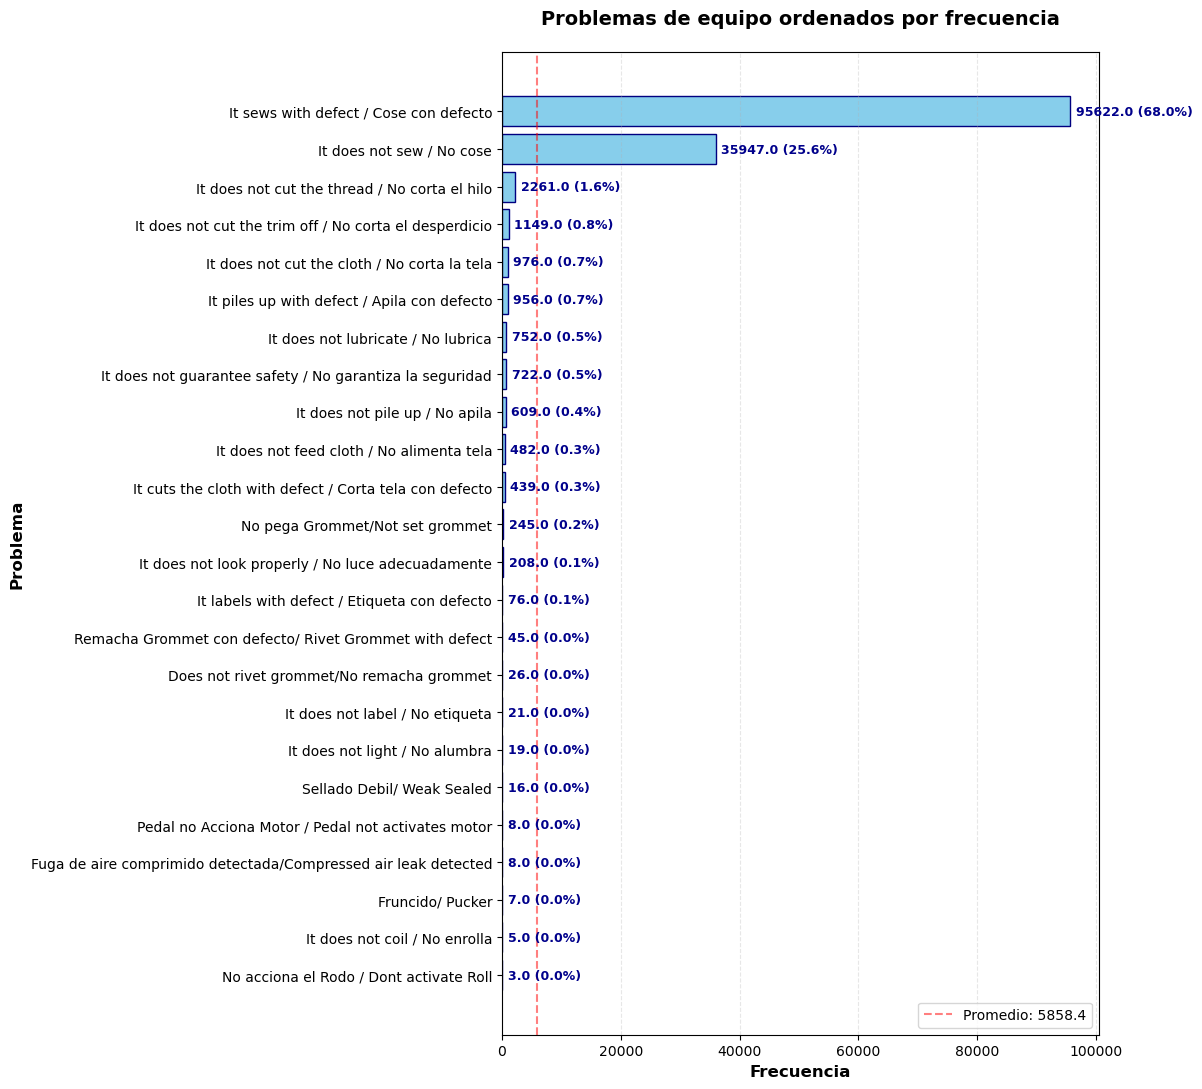


📊 ESTADÍSTICAS DE PROBLEMAS:
Total de problemas: 24
Total de eventos: 140602
Problema más frecuente: It sews with defect / Cose con defecto (95622 eventos)
Problema menos frecuente: No acciona el Rodo / Dont activate Roll (3 eventos)

Top 5 problemas por frecuencia:
                                                    count  percentage
problem_desc                                                         
It sews with defect / Cose con defecto              95622        68.0
It does not sew / No cose                           35947        25.6
It does not cut the thread / No corta el hilo        2261         1.6
It does not cut the trim off / No corta el desp...   1149         0.8
It does not cut the cloth / No corta la tela          976         0.7


In [202]:
# Calcular porcentaje acumulado para línea de Pareto (opcional)
df_problemas['percentage'] = (df_problemas['count'] / df_problemas['count'].sum() * 100).round(1)
df_problemas['cum_percentage'] = df_problemas['percentage'].cumsum()

# Ordenar
df_sorted = df_problemas.sort_values(by='count')

# Crear gráfico
fig, ax1 = plt.subplots(figsize=(12, 11))

# Barras horizontales
bars = ax1.barh(df_sorted.index, df_sorted['count'], color='skyblue', edgecolor='navy')

# Agregar etiquetas con conteo y porcentaje
for i, (idx, row) in enumerate(df_sorted.iterrows()):
    # Posición de la barra
    bar = bars[i]
    width = bar.get_width()
    
    # Texto con conteo y porcentaje
    label = f"{row['count']} ({row['percentage']}%)"
    
    # Posicionar el texto al final de la barra
    ax1.text(width + (df_sorted['count'].max() * 0.01), 
             bar.get_y() + bar.get_height()/2,
             label, 
             va='center', 
             ha='left',
             fontsize=9,
             fontweight='bold',
             color='darkblue')

# Personalización
ax1.set_xlabel('Frecuencia', fontsize=12, fontweight='bold')
ax1.set_ylabel('Problema', fontsize=12, fontweight='bold')
ax1.set_title('Problemas de equipo ordenados por frecuencia', 
              fontsize=14, fontweight='bold', pad=20)

# Agregar grid para mejor legibilidad
ax1.grid(axis='x', alpha=0.3, linestyle='--')

# Agregar línea de promedio (opcional)
avg_count = df_sorted['count'].mean()
ax1.axvline(x=avg_count, color='red', linestyle='--', alpha=0.5, 
            label=f'Promedio: {avg_count:.1f}')
ax1.legend(loc='lower right')

plt.tight_layout()
plt.show()

# Mostrar estadísticas
print("\n📊 ESTADÍSTICAS DE PROBLEMAS:")
print(f"Total de problemas: {len(df_problemas)}")
print(f"Total de eventos: {df_problemas['count'].sum()}")
print(f"Problema más frecuente: {df_problemas['count'].idxmax()} ({df_problemas['count'].max()} eventos)")
print(f"Problema menos frecuente: {df_problemas['count'].idxmin()} ({df_problemas['count'].min()} eventos)")
print(f"\nTop 5 problemas por frecuencia:")
print(df_problemas.nlargest(5, 'count')[['count', 'percentage']])

#### Creamos la columna **problem_grupo** en que el valor será igual a descripción de falla si cum_percentage < 95 y Otros en caso contrario

In [203]:
df_problemas['problem_grupo'] = df_problemas.index

condicion = df_problemas['cum_percentage'] < 95

df_problemas['problem_grupo'] = df_problemas['problem_grupo'].map(
    lambda x: x if condicion[df_problemas['problem_grupo'] == x].any() else 'Otros'
)

In [204]:
df_problemas.head(5)

,count,percentage,cum_percentage,problem_grupo
problem_desc,,,,
It sews with defect / Cose con defecto,95622,68.0,68.0,It sews with defect / Cose con defecto
It does not sew / No cose,35947,25.6,93.6,It does not sew / No cose
It does not cut the thread / No corta el hilo,2261,1.6,95.2,Otros
It does not cut the trim off / No corta el desperdicio,1149,0.8,96.0,Otros
It does not cut the cloth / No corta la tela,976,0.7,96.7,Otros


#### Creamos la varible **problem_grupo** en el dataset de fallos

In [205]:
df['problem_grupo'] = df['problem_desc'].map(df_problemas['problem_grupo'].to_dict())
df['problem_grupo'].value_counts()

problem_grupo
It sews with defect / Cose con defecto    95622
It does not sew / No cose                 35947
Otros                                      9033
Name: count, dtype: int64

#### Creamos dataframe con problemas agrupados por grupos de problema

In [206]:
df_problemas_agrupados = df.groupby(['problem_grupo'])['downtime_gross'].agg(['count', 'sum'])
df_problemas_agrupados['sum'] = df_problemas_agrupados['sum'].astype(int)

In [207]:
# df_problemas_agrupados = pd.DataFrame(df['problem_grupo'].value_counts())
df_problemas_agrupados

,count,sum
problem_grupo,,
It does not sew / No cose,35947,37968
It sews with defect / Cose con defecto,95622,161617
Otros,9033,12207


#### Asignamos colores para el grafico de barras de problemas

In [208]:
color_dict_problemas = {
    'It does not sew / No cose': "#1f53b4", 
    'It sews with defect / Cose con defecto': "#c05619c8", 
    'Otros': "#27a7a7" 
}

bar_colors_problemas = [color_dict_problemas.get(grupo) for grupo in df_problemas_agrupados.index]
bar_colors_problemas

['#1f53b4', '#c05619c8', '#27a7a7']

### Grafico de barras de problemas. Frecuencia de fallos.

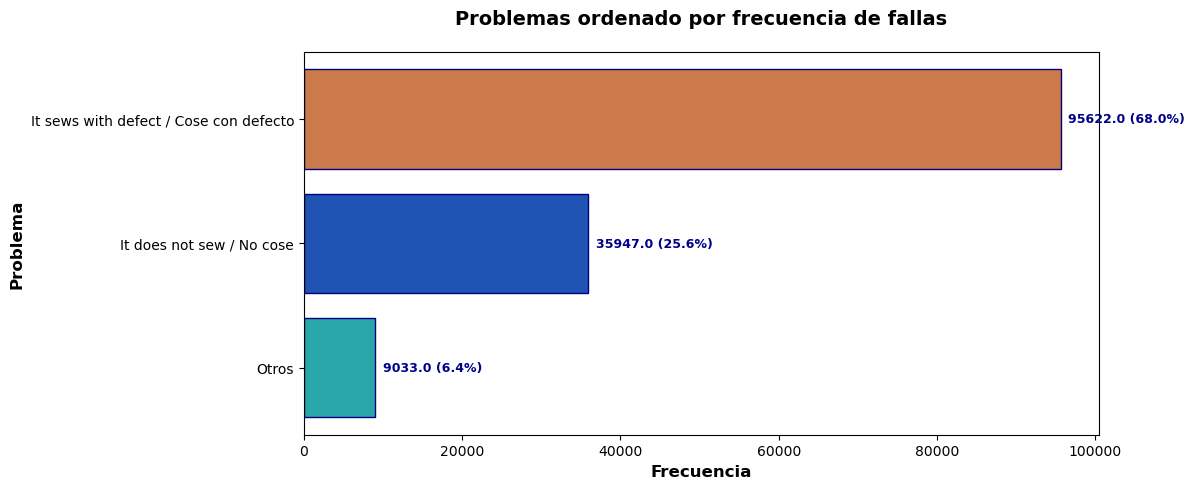


📊 ESTADÍSTICAS DE FALLOS:
Total de problemas: 3
Total de eventos: 140602
Problema más frecuente: It sews with defect / Cose con defecto (95622 eventos)
Problema menos frecuente: Otros (9033 eventos)


In [209]:
# Calcular porcentaje acumulado para línea de Pareto (opcional)
df_problemas_agrupados['percentage'] = (df_problemas_agrupados['count'] / df_problemas_agrupados['count'].sum() * 100).round(1)
df_problemas_agrupados['cum_percentage'] = df_problemas_agrupados['percentage'].cumsum()

# Ordenar
df_sorted = df_problemas_agrupados.sort_values(by='count')

# Crear gráfico
fig, ax1 = plt.subplots(figsize=(12, 5))

# Asignar colores basados en falla_grupo
bar_colors = [color_dict_problemas.get(grupo) for grupo in df_sorted.index]

# Barras horizontales
bars = ax1.barh(df_sorted.index, df_sorted['count'], color=bar_colors, edgecolor='navy')

# Agregar etiquetas con conteo y porcentaje
for i, (idx, row) in enumerate(df_sorted.iterrows()):
    # Posición de la barra
    bar = bars[i]
    width = bar.get_width()
    
    # Texto con conteo y porcentaje
    label = f"{row['count']} ({row['percentage']}%)"
    
    # Posicionar el texto al final de la barra
    ax1.text(width + (df_sorted['count'].max() * 0.01), 
             bar.get_y() + bar.get_height()/2,
             label, 
             va='center', 
             ha='left',
             fontsize=9,
             fontweight='bold',
             color='darkblue')

# Personalización
ax1.set_xlabel('Frecuencia', fontsize=12, fontweight='bold')
ax1.set_ylabel('Problema', fontsize=12, fontweight='bold')
ax1.set_title('Problemas ordenado por frecuencia de fallas', 
              fontsize=14, fontweight='bold', pad=20)

# Agregar grid para mejor legibilidad
# ax1.grid(axis='x', alpha=0.3, linestyle='--')

# # Agregar línea de promedio (opcional)
# avg_count = df_sorted['count'].mean()
# ax1.axvline(x=avg_count, color='red', linestyle='--', alpha=0.5, 
#             label=f'Promedio: {avg_count:.1f}')
# ax1.legend(loc='lower right')

plt.tight_layout()
plt.show()

# Mostrar estadísticas
print("\n📊 ESTADÍSTICAS DE FALLOS:")
print(f"Total de problemas: {len(df_problemas_agrupados)}")
print(f"Total de eventos: {df_problemas_agrupados['count'].sum()}")
print(f"Problema más frecuente: {df_problemas_agrupados['count'].idxmax()} ({df_problemas_agrupados['count'].max()} eventos)")
print(f"Problema menos frecuente: {df_problemas_agrupados['count'].idxmin()} ({df_problemas_agrupados['count'].min()} eventos)")

### Grafico de barras de problemas. Tiempo de paro.

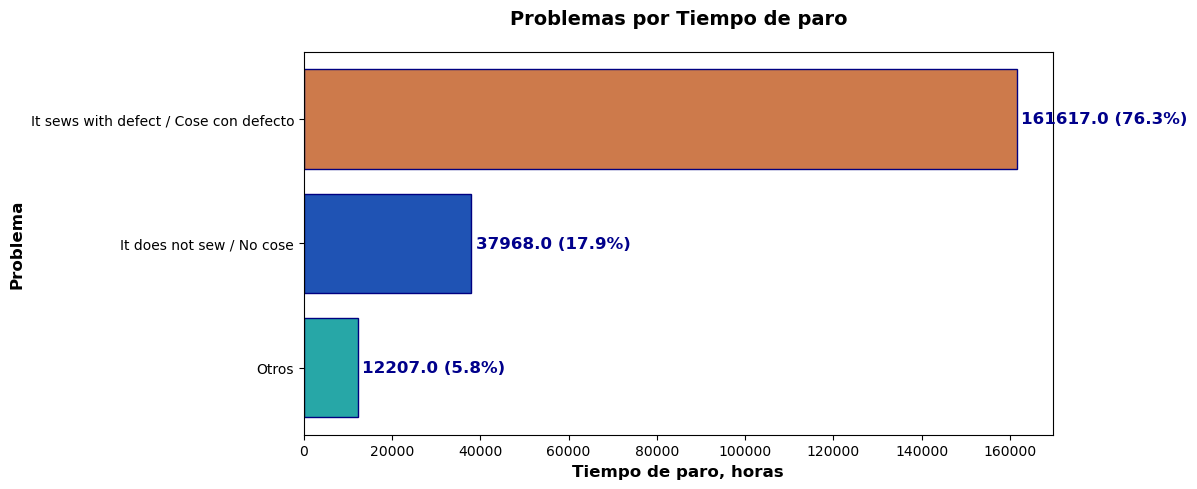


📊 ESTADÍSTICAS DE FALLOS:
Total de problemas: 3
Total de eventos: 140602
Problema más frecuente: It sews with defect / Cose con defecto (161617 horas)
Problema menos frecuente: Otros (12207 horas)


In [210]:
# Calcular porcentaje acumulado para línea de Pareto (opcional)
df_problemas_agrupados['percentage'] = (df_problemas_agrupados['sum'] / df_problemas_agrupados['sum'].sum() * 100).round(1)
df_problemas_agrupados['cum_percentage'] = df_problemas_agrupados['percentage'].cumsum()

# Ordenar
df_sorted = df_problemas_agrupados.sort_values(by='sum')

# Crear gráfico
fig, ax1 = plt.subplots(figsize=(12, 5))

# Asignar colores basados en falla_grupo
bar_colors = [color_dict_problemas.get(grupo) for grupo in df_sorted.index]

# Barras horizontales
bars = ax1.barh(df_sorted.index, df_sorted['sum'], color=bar_colors, edgecolor='navy')

# Agregar etiquetas con conteo y porcentaje
for i, (idx, row) in enumerate(df_sorted.iterrows()):
    # Posición de la barra
    bar = bars[i]
    width = bar.get_width()
    
    # Texto con conteo y porcentaje
    label = f"{row['sum']} ({row['percentage']}%)"
    
    # Posicionar el texto al final de la barra
    ax1.text(width + (df_sorted['count'].max() * 0.01), 
             bar.get_y() + bar.get_height()/2,
             label, 
             va='center', 
             ha='left',
             fontsize=12,
             fontweight='bold',
             color='darkblue')

# Personalización
ax1.set_xlabel('Tiempo de paro, horas', fontsize=12, fontweight='bold')
ax1.set_ylabel('Problema', fontsize=12, fontweight='bold')
ax1.set_title('Problemas por Tiempo de paro', 
              fontsize=14, fontweight='bold', pad=20)

# Agregar grid para mejor legibilidad
# ax1.grid(axis='x', alpha=0.3, linestyle='--')

# # Agregar línea de promedio (opcional)
# avg_count = df_sorted['count'].mean()
# ax1.axvline(x=avg_count, color='red', linestyle='--', alpha=0.5, 
#             label=f'Promedio: {avg_count:.1f}')
# ax1.legend(loc='lower right')

plt.tight_layout()
plt.show()

# Mostrar estadísticas
print("\n📊 ESTADÍSTICAS DE FALLOS:")
print(f"Total de problemas: {len(df_problemas_agrupados)}")
print(f"Total de eventos: {df_problemas_agrupados['count'].sum()}")
print(f"Problema más frecuente: {df_problemas_agrupados['count'].idxmax()} ({df_problemas_agrupados['sum'].max()} horas)")
print(f"Problema menos frecuente: {df_problemas_agrupados['count'].idxmin()} ({df_problemas_agrupados['sum'].min()} horas)")

#### Frecuencia de **fallas por mes y grupo o de problema**. **Grafico de barras apilladas.**

In [211]:
df_fallas_por_mes_problema_grupo = pd.crosstab(df['mes'], df['problem_grupo'])
df_fallas_por_mes_problema_grupo
df_fallas_por_mes_problema_grupo.columns.to_list()

['It does not sew / No cose',
 'It sews with defect / Cose con defecto',
 'Otros']

In [212]:
bar_colors_problemas_agrupado = [color_dict_problemas.get(grupo) for grupo in df_fallas_por_mes_problema_grupo.columns]
bar_colors_problemas_agrupado

['#1f53b4', '#c05619c8', '#27a7a7']

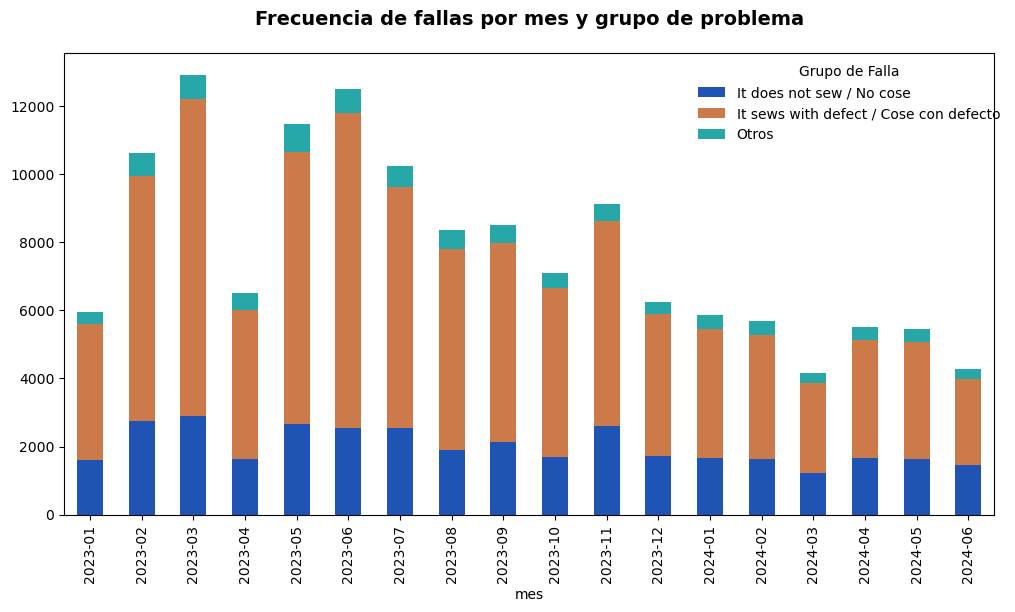

In [213]:
ax = df_fallas_por_mes_problema_grupo.plot.bar(figsize=(12, 6), stacked=True, color = bar_colors_problemas_agrupado)

ax.set_title('Frecuencia de fallas por mes y grupo de problema', fontsize=14, fontweight='bold', pad=20)
ax.legend(
    title='Grupo de Falla',
    loc='best',           
    bbox_to_anchor=(1.02, 1),    # 1.02 la mueve justo fuera del gráfico a la derecha
    ncol=1,                      # Asegura una sola columna (un valor por línea)
    frameon=False                # Opcional: quita el recuadro para un look más limpio
)

plt.show()

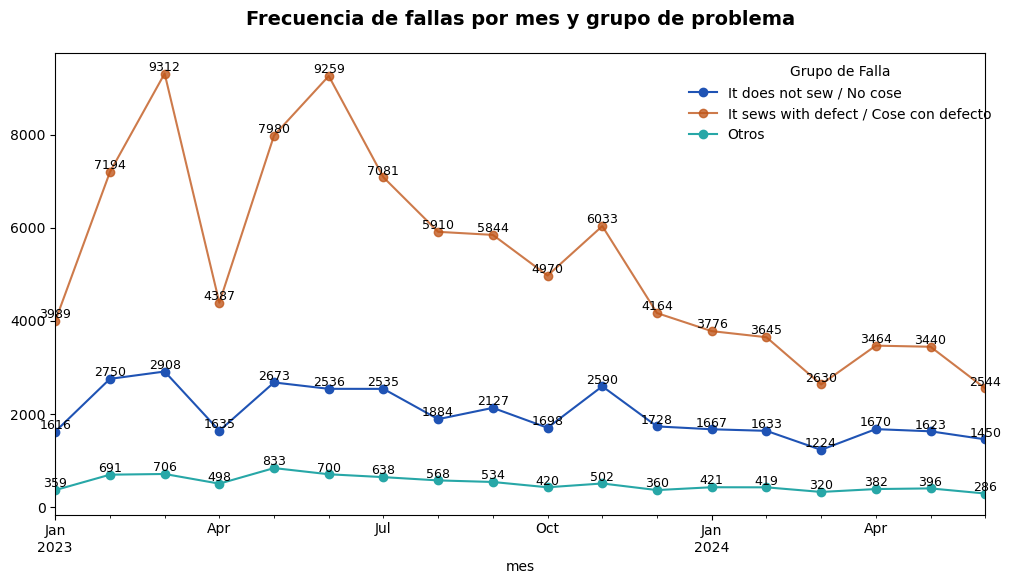

In [214]:
ax = df_fallas_por_mes_problema_grupo.plot.line(figsize=(12, 6), color = bar_colors_problemas_agrupado, marker='o')

# Agregar números en cada punto
for line in ax.lines:
    for x, y in zip(line.get_xdata(), line.get_ydata()):
        ax.text(
            x,
            y,
            f'{int(y)}',
            ha='center',
            va='bottom',
            fontsize=9
        )

ax.set_title('Frecuencia de fallas por mes y grupo de problema', fontsize=14, fontweight='bold', pad=20)
ax.legend(
    title='Grupo de Falla',
    loc='best',           
    bbox_to_anchor=(1.02, 1),    # 1.02 la mueve justo fuera del gráfico a la derecha
    ncol=1,                      # Asegura una sola columna (un valor por línea)
    frameon=False                # Opcional: quita el recuadro para un look más limpio
)

plt.show()

## Fallas más frecuentes **failure_desc**

In [215]:
df_fallas = pd.DataFrame(df['failure_desc'].value_counts())
print('Número de fallos unicos', df_fallas.shape[0])
df_fallas.head(10)

Número de fallos unicos 38


,count
failure_desc,
Machine head failure stopping sewing / Falla cabezal dejando de coser,67899
Machine head failure sewing with defect / Falla cabezal cosiendo con defecto,36912
Trim off device failure / Falla dispositivo corta desperdicio,13436
Chain cutter failure / Falla corta cadenetas,3044
Folder failure / Falla doblillador,2942
Monitoring and control failure / Falla monitoreo y control,2119
Engine failure / Falla motor,1986
Lubrication system failure / Falla sistema de lubricación,1892
Stacker failure it stops piling up / Falla apilador dejando de apilar,1504


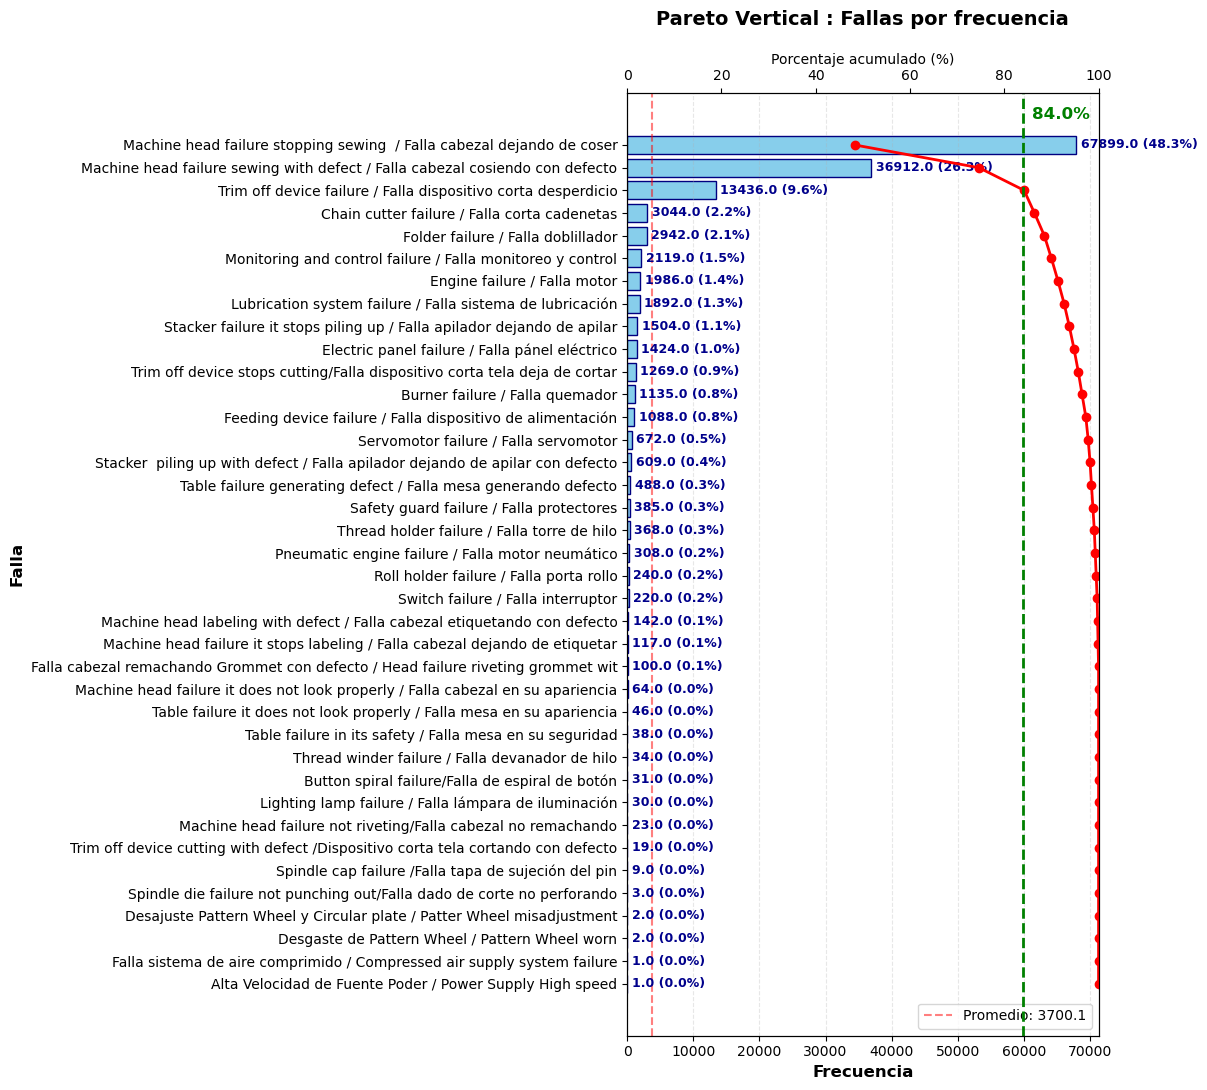


📊 ESTADÍSTICAS DE FALLOS:
Total de fallos: 38
Total de eventos: 140602
Problema más frecuente: Machine head failure stopping sewing  / Falla cabezal dejando de coser (67899 eventos)
Problema menos frecuente: Falla sistema de aire comprimido / Compressed air supply system failure (1 eventos)

Top 5 fallos por frecuencia:
                                                    count  percentage
failure_desc                                                         
Machine head failure stopping sewing  / Falla c...  67899        48.3
Machine head failure sewing with defect / Falla...  36912        26.3
Trim off device failure / Falla dispositivo cor...  13436         9.6
Chain cutter failure / Falla corta cadenetas         3044         2.2
Folder failure / Falla doblillador                   2942         2.1


In [216]:
# Calcular porcentaje acumulado para línea de Pareto (opcional)
df_fallas['percentage'] = (df_fallas['count'] / df_fallas['count'].sum() * 100).round(1)
df_fallas['cum_percentage'] = df_fallas['percentage'].cumsum()

# Ordenar
df_sorted = df_fallas.sort_values(by='count')

# Crear gráfico
fig, ax1 = plt.subplots(figsize=(12, 11))

# Barras horizontales
bars = ax1.barh(df_sorted.index, df_sorted['count'], color='skyblue', edgecolor='navy')

# Agregar etiquetas con conteo y porcentaje
for i, (idx, row) in enumerate(df_sorted.iterrows()):
    # Posición de la barra
    bar = bars[i]
    width = bar.get_width()
    
    # Texto con conteo y porcentaje
    label = f"{row['count']} ({row['percentage']}%)"
    
    # Posicionar el texto al final de la barra
    ax1.text(width + (df_sorted['count'].max() * 0.01), 
             bar.get_y() + bar.get_height()/2,
             label, 
             va='center', 
             ha='left',
             fontsize=9,
             fontweight='bold',
             color='darkblue')

# Personalización
ax1.set_xlabel('Frecuencia', fontsize=12, fontweight='bold')
ax1.set_ylabel('Falla', fontsize=12, fontweight='bold')
ax1.set_title('Pareto Vertical : Fallas por frecuencia', 
              fontsize=14, fontweight='bold', pad=20)

# Agregar grid para mejor legibilidad
ax1.grid(axis='x', alpha=0.3, linestyle='--')

# Agregar línea de promedio (opcional)
avg_count = df_sorted['count'].mean()
ax1.axvline(x=avg_count, color='red', linestyle='--', alpha=0.5, 
            label=f'Promedio: {avg_count:.1f}')
ax1.legend(loc='lower right')

# Crear segundo eje para porcentaje acumulado
ax2 = ax1.twiny()

# Curva de Pareto
ax2.plot(
    df_sorted['cum_percentage'],
    df_sorted.index,
    color='red',
    marker='o',
    linewidth=2
)

ax2.set_xlim(0,100)
ax2.set_xlabel('Porcentaje acumulado (%)')

linia_de_3_primeros_fallas = round(df_fallas['cum_percentage'][2],0)
# Línea del 3 primeros fallas
ax2.axvline(linia_de_3_primeros_fallas, color='green', linestyle='--', linewidth=2)

ax2.text(
    92,                   # posición X
    len(df_sorted), # posición Y (parte superior del gráfico)
    str(linia_de_3_primeros_fallas) + '%',
    color='green',
    fontsize=12,
    fontweight='bold',
    ha='center',
    va='bottom'
)


plt.tight_layout()
plt.show()

# Mostrar estadísticas
print("\n📊 ESTADÍSTICAS DE FALLOS:")
print(f"Total de fallos: {len(df_fallas)}")
print(f"Total de eventos: {df_fallas['count'].sum()}")
print(f"Problema más frecuente: {df_fallas['count'].idxmax()} ({df_fallas['count'].max()} eventos)")
print(f"Problema menos frecuente: {df_fallas['count'].idxmin()} ({df_fallas['count'].min()} eventos)")
print(f"\nTop 5 fallos por frecuencia:")
print(df_fallas.nlargest(5, 'count')[['count', 'percentage']])

In [217]:
df_fallas.head(5)


,count,percentage,cum_percentage
failure_desc,,,
Machine head failure stopping sewing / Falla cabezal dejando de coser,67899,48.3,48.3
Machine head failure sewing with defect / Falla cabezal cosiendo con defecto,36912,26.3,74.6
Trim off device failure / Falla dispositivo corta desperdicio,13436,9.6,84.2
Chain cutter failure / Falla corta cadenetas,3044,2.2,86.4
Folder failure / Falla doblillador,2942,2.1,88.5


#### Creamos la columna **falla_grupo** en que el valor será igual a descripción de falla si cum_percentage < 85 y Otros en caso contrario

In [218]:
df_fallas['falla_grupo'] = df_fallas.index

condicion = df_fallas['cum_percentage'] < 85

df_fallas['falla_grupo'] = df_fallas['falla_grupo'].map(
    lambda x: x if condicion[df_fallas['falla_grupo'] == x].any() else 'Otros'
)

#### Creamos la varible **falla_grupo** en el dataset de fallos

In [219]:
df['falla_grupo'] = df['failure_desc'].map(df_fallas['falla_grupo'].to_dict())

#### Creamos dataframe con fallas agrupadas por tipo de falla

In [220]:
df_fallas_agrupados = df.groupby('falla_grupo')['downtime_gross'].agg(['count', 'sum'])
df_fallas_agrupados['sum'] = df_fallas_agrupados['sum'].astype(int) 
df_fallas_agrupados

,count,sum
falla_grupo,,
Machine head failure sewing with defect / Falla cabezal cosiendo con defecto,36912,59613
Machine head failure stopping sewing / Falla cabezal dejando de coser,67899,98118
Otros,22355,38553
Trim off device failure / Falla dispositivo corta desperdicio,13436,15506


In [221]:
df_fallas_agrupados['percentage'] = (df_fallas_agrupados['count'] / df_fallas_agrupados['count'].sum() * 100).round(1)
df_fallas_agrupados['cum_percentage'] = df_fallas_agrupados['percentage'].cumsum()

# Ordenar
df_sorted = df_fallas_agrupados.sort_values(by='count')

In [222]:
df_fallas_agrupados

,count,sum,percentage,cum_percentage
falla_grupo,,,,
Machine head failure sewing with defect / Falla cabezal cosiendo con defecto,36912,59613,26.3,26.3
Machine head failure stopping sewing / Falla cabezal dejando de coser,67899,98118,48.3,74.6
Otros,22355,38553,15.9,90.5
Trim off device failure / Falla dispositivo corta desperdicio,13436,15506,9.6,100.1


### Asignamos los colores para el grafico de barras de fallos

In [223]:
color_dict = {
    'Machine head failure stopping sewing  / Falla cabezal dejando de coser': "#1f53b4", 
    'Machine head failure sewing with defect / Falla cabezal cosiendo con defecto': "#c05619c8", 
    'Trim off device failure / Falla dispositivo corta desperdicio': "#2ca07d", 
    'Otros': "#27d6d6" 
}

In [224]:
bar_colors = [color_dict.get(grupo) for grupo in df_fallas_agrupados.index]
bar_colors

['#c05619c8', '#1f53b4', '#27d6d6', '#2ca07d']

### Grafico de barras de grupos de fallas. Frecuencia de fallos.

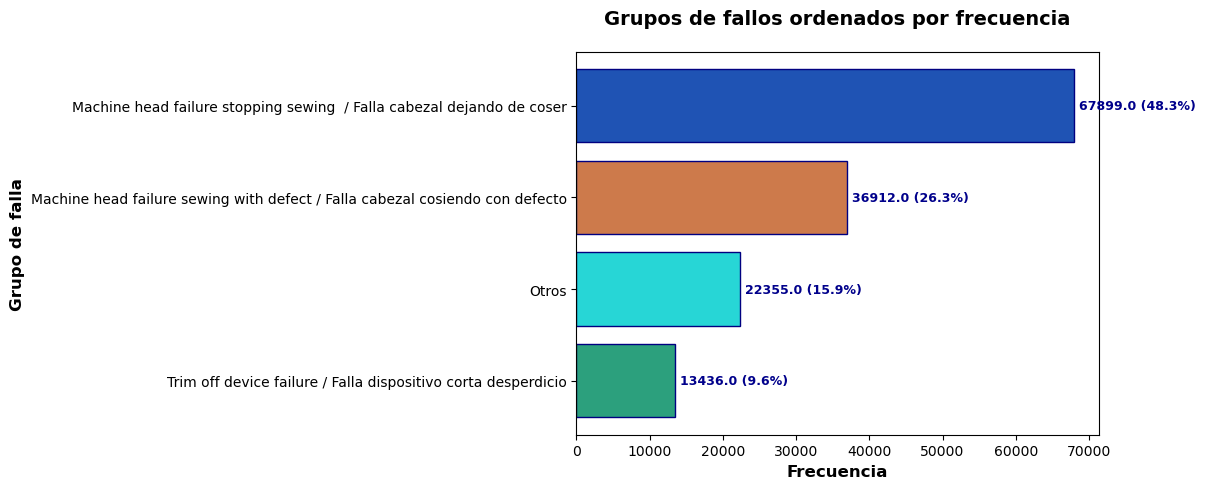


📊 ESTADÍSTICAS DE FALLOS:
Total de fallos: 4
Total de eventos: 140602
Falla más frecuente: Machine head failure stopping sewing  / Falla cabezal dejando de coser (67899 eventos)
Falla menos frecuente: Trim off device failure / Falla dispositivo corta desperdicio (13436 eventos)


In [225]:
# Calcular porcentaje acumulado para línea de Pareto (opcional)
df_fallas_agrupados['percentage'] = (df_fallas_agrupados['count'] / df_fallas_agrupados['count'].sum() * 100).round(1)
df_fallas_agrupados['cum_percentage'] = df_fallas_agrupados['percentage'].cumsum()

# Ordenar
df_sorted = df_fallas_agrupados.sort_values(by='count')

# Crear gráfico
fig, ax1 = plt.subplots(figsize=(12, 5))

# Asignar colores basados en falla_grupo
bar_colors = [color_dict.get(grupo) for grupo in df_sorted.index]

# Barras horizontales
bars = ax1.barh(df_sorted.index, df_sorted['count'], color=bar_colors, edgecolor='navy')

# Agregar etiquetas con conteo y porcentaje
for i, (idx, row) in enumerate(df_sorted.iterrows()):
    # Posición de la barra
    bar = bars[i]
    width = bar.get_width()
    
    # Texto con conteo y porcentaje
    label = f"{row['count']} ({row['percentage']}%)"
    
    # Posicionar el texto al final de la barra
    ax1.text(width + (df_sorted['count'].max() * 0.01), 
             bar.get_y() + bar.get_height()/2,
             label, 
             va='center', 
             ha='left',
             fontsize=9,
             fontweight='bold',
             color='darkblue')

# Personalización
ax1.set_xlabel('Frecuencia', fontsize=12, fontweight='bold')
ax1.set_ylabel('Grupo de falla', fontsize=12, fontweight='bold')
ax1.set_title('Grupos de fallos ordenados por frecuencia', 
              fontsize=14, fontweight='bold', pad=20)

# Agregar grid para mejor legibilidad
# ax1.grid(axis='x', alpha=0.3, linestyle='--')

# # Agregar línea de promedio (opcional)
# avg_count = df_sorted['count'].mean()
# ax1.axvline(x=avg_count, color='red', linestyle='--', alpha=0.5, 
#             label=f'Promedio: {avg_count:.1f}')
# ax1.legend(loc='lower right')

plt.tight_layout()
plt.show()

# Mostrar estadísticas
print("\n📊 ESTADÍSTICAS DE FALLOS:")
print(f"Total de fallos: {len(df_fallas_agrupados)}")
print(f"Total de eventos: {df_fallas_agrupados['count'].sum()}")
print(f"Falla más frecuente: {df_fallas_agrupados['count'].idxmax()} ({df_fallas_agrupados['count'].max()} eventos)")
print(f"Falla menos frecuente: {df_fallas_agrupados['count'].idxmin()} ({df_fallas_agrupados['count'].min()} eventos)")

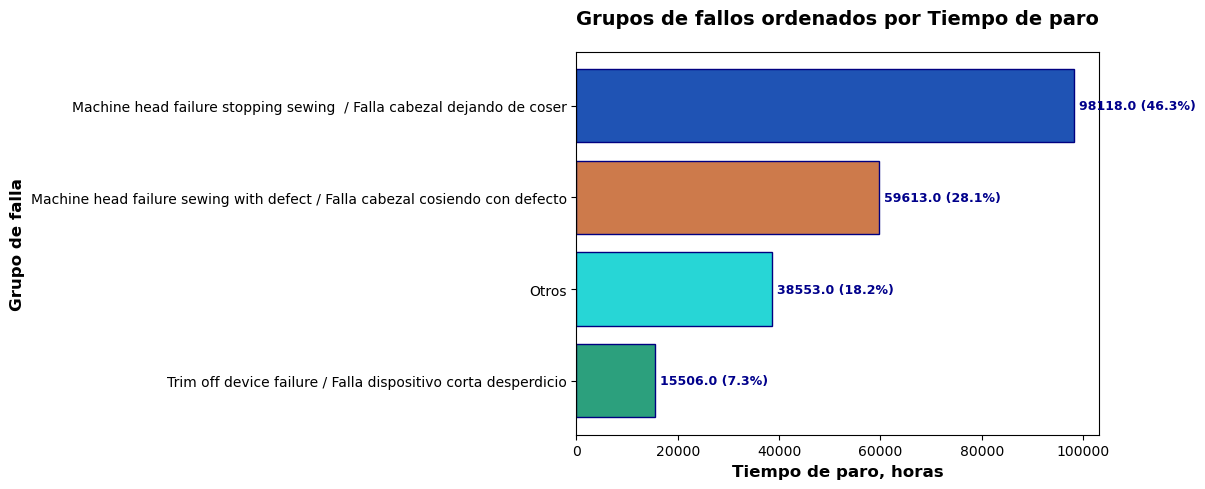


📊 ESTADÍSTICAS DE FALLOS:
Total de fallos: 4
Total de eventos: 140602
Falla más frecuente: Machine head failure stopping sewing  / Falla cabezal dejando de coser (67899 eventos)
Falla menos frecuente: Trim off device failure / Falla dispositivo corta desperdicio (13436 eventos)


In [226]:
# Calcular porcentaje acumulado para línea de Pareto (opcional)
df_fallas_agrupados['percentage'] = (df_fallas_agrupados['sum'] / df_fallas_agrupados['sum'].sum() * 100).round(1)
df_fallas_agrupados['cum_percentage'] = df_fallas_agrupados['percentage'].cumsum()

# Ordenar
df_sorted = df_fallas_agrupados.sort_values(by='sum')

# Crear gráfico
fig, ax1 = plt.subplots(figsize=(12, 5))

# Asignar colores basados en falla_grupo
bar_colors = [color_dict.get(grupo) for grupo in df_sorted.index]

# Barras horizontales
bars = ax1.barh(df_sorted.index, df_sorted['sum'], color=bar_colors, edgecolor='navy')

# Agregar etiquetas con conteo y porcentaje
for i, (idx, row) in enumerate(df_sorted.iterrows()):
    # Posición de la barra
    bar = bars[i]
    width = bar.get_width()
    
    # Texto con conteo y porcentaje
    label = f"{row['sum']} ({row['percentage']}%)"
    
    # Posicionar el texto al final de la barra
    ax1.text(width + (df_sorted['sum'].max() * 0.01), 
             bar.get_y() + bar.get_height()/2,
             label, 
             va='center', 
             ha='left',
             fontsize=9,
             fontweight='bold',
             color='darkblue')

# Personalización
ax1.set_xlabel('Tiempo de paro, horas', fontsize=12, fontweight='bold')
ax1.set_ylabel('Grupo de falla', fontsize=12, fontweight='bold')
ax1.set_title('Grupos de fallos ordenados por Tiempo de paro', 
              fontsize=14, fontweight='bold', pad=20)

# Agregar grid para mejor legibilidad
# ax1.grid(axis='x', alpha=0.3, linestyle='--')

# # Agregar línea de promedio (opcional)
# avg_count = df_sorted['count'].mean()
# ax1.axvline(x=avg_count, color='red', linestyle='--', alpha=0.5, 
#             label=f'Promedio: {avg_count:.1f}')
# ax1.legend(loc='lower right')

plt.tight_layout()
plt.show()

# Mostrar estadísticas
print("\n📊 ESTADÍSTICAS DE FALLOS:")
print(f"Total de fallos: {len(df_fallas_agrupados)}")
print(f"Total de eventos: {df_fallas_agrupados['count'].sum()}")
print(f"Falla más frecuente: {df_fallas_agrupados['count'].idxmax()} ({df_fallas_agrupados['count'].max()} eventos)")
print(f"Falla menos frecuente: {df_fallas_agrupados['count'].idxmin()} ({df_fallas_agrupados['count'].min()} eventos)")

In [227]:
df_sorted

,count,sum,percentage,cum_percentage
falla_grupo,,,,
Trim off device failure / Falla dispositivo corta desperdicio,13436,15506,7.3,99.9
Otros,22355,38553,18.2,92.6
Machine head failure sewing with defect / Falla cabezal cosiendo con defecto,36912,59613,28.1,28.1
Machine head failure stopping sewing / Falla cabezal dejando de coser,67899,98118,46.3,74.4


#### Fercuencia de **fallos por mes y tipo de falla**. **Grafico de barras apilladas.**

In [228]:
df_fallas_por_mes_falla_grupo = pd.crosstab(df['mes'], df['falla_grupo'])
df_fallas_por_mes_falla_grupo
df_fallas_por_mes_falla_grupo.columns.to_list()

['Machine head failure sewing with defect / Falla cabezal cosiendo con defecto',
 'Machine head failure stopping sewing  / Falla cabezal dejando de coser',
 'Otros',
 'Trim off device failure / Falla dispositivo corta desperdicio']

In [229]:
bar_colors = [color_dict.get(grupo) for grupo in df_fallas_por_mes_falla_grupo.columns]
bar_colors

['#c05619c8', '#1f53b4', '#27d6d6', '#2ca07d']

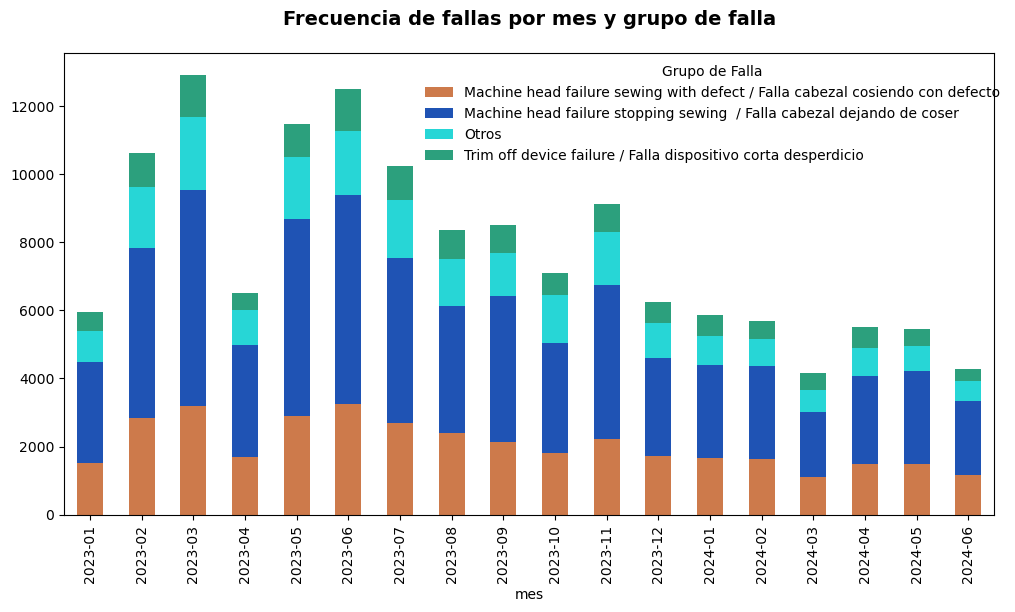

In [230]:
ax = df_fallas_por_mes_falla_grupo.plot.bar(figsize=(12, 6), stacked=True, color = bar_colors)

ax.set_title('Frecuencia de fallas por mes y grupo de falla', fontsize=14, fontweight='bold', pad=20)
ax.legend(
    title='Grupo de Falla',
    loc='best',           # Punto de anclaje de la leyenda (esquina sup. izq.)
    bbox_to_anchor=(1.02, 1),    # 1.02 la mueve justo fuera del gráfico a la derecha
    ncol=1,                      # Asegura una sola columna (un valor por línea)
    frameon=False                # Opcional: quita el recuadro para un look más limpio
)

plt.show()

### Grafico de linias

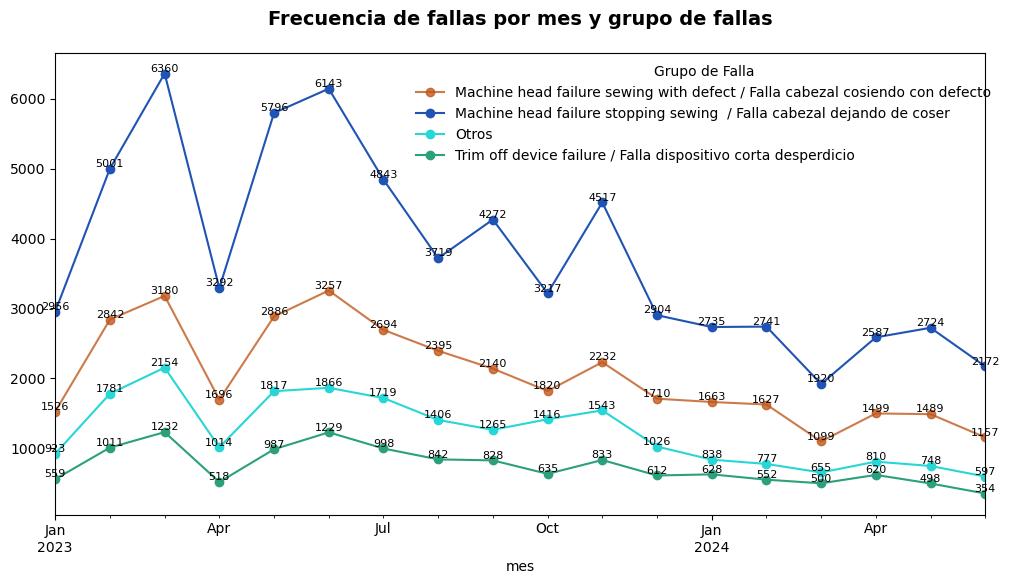

In [231]:
ax = df_fallas_por_mes_falla_grupo.plot.line(figsize=(12, 6), color = bar_colors, marker='o')

# Agregar números en cada punto
for line in ax.lines:
    for x, y in zip(line.get_xdata(), line.get_ydata()):
        ax.text(
            x,
            y,
            f'{int(y)}',
            ha='center',
            va='bottom',
            fontsize=8
        )

ax.set_title('Frecuencia de fallas por mes y grupo de fallas', fontsize=14, fontweight='bold', pad=20)
ax.legend(
    title='Grupo de Falla',
    loc='best',           
    bbox_to_anchor=(1.02, 1),    # 1.02 la mueve justo fuera del gráfico a la derecha
    ncol=1,                      # Asegura una sola columna (un valor por línea)
    frameon=False                # Opcional: quita el recuadro para un look más limpio
)

plt.show()

### Guardamos dataset de fallos con nuevas variables agregados: **problem_grupo, falla_grupo**.

In [232]:
df.to_parquet('../Dataset limpiado/dataset unificado.parquet')

#### Distribición de tiempo de paro por tipo de fallos

In [233]:
df_hist_downtime_gross_por_tipo_falla = df[['falla_grupo', 'downtime_gross']]

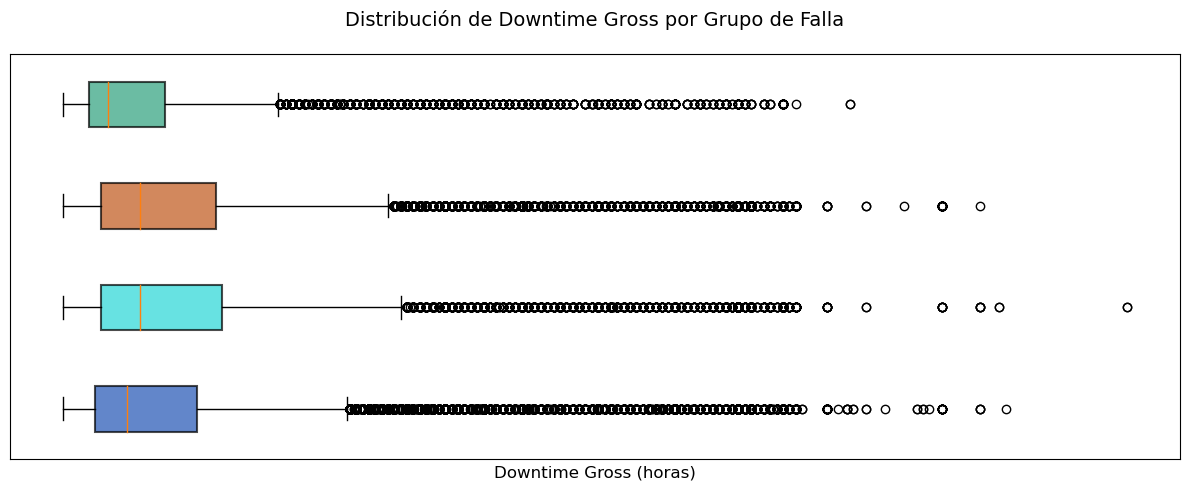

In [234]:
box_colors = [color_dict.get(grupo) for grupo in df_hist_downtime_gross_por_tipo_falla['falla_grupo']]

plt.figure(figsize=(12, 5))

# Boxplot con matplotlib para control total
fallas_unicas = df_hist_downtime_gross_por_tipo_falla['falla_grupo'].unique()
data = [df_hist_downtime_gross_por_tipo_falla[df_hist_downtime_gross_por_tipo_falla['falla_grupo'] == falla]['downtime_gross'].dropna() 
        for falla in fallas_unicas]

bp = plt.boxplot(data, 
                 labels=fallas_unicas,
                 vert=False,
                 patch_artist=True)

# Asignar colores según el diccionario
for box, falla in zip(bp['boxes'], fallas_unicas):
    box.set_facecolor(color_dict.get(falla))  # Color por defecto si no existe
    box.set_alpha(0.7)
    box.set_edgecolor('black')
    box.set_linewidth(1.5)

plt.title('Distribución de Downtime Gross por Grupo de Falla', fontsize=14, pad=20)
plt.xlabel('Downtime Gross (horas)', fontsize=12)
plt.ylabel('')
plt.xticks([])
plt.yticks([])
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()